# Assignment 4 — Explore Orchestration Frameworks (LangGraph)

Goal: rebuild the Assignment 3 multi-agent setup using **LangGraph**
(graph-based orchestration), with explicit node-level roles and a
**conditional branch**:

> If topic = finance -> use `FinanceAgent`; else -> use `GeneralAgent`.

Graph shape:

```
        classify_topic
              |
            search
        /          \
finance_analysis   general_analysis
        \          /
            report
              |
             END
```

We use LangGraph rather than CrewAI because CrewAI's agent classes are
built around hosted-LLM clients (OpenAI, Anthropic, etc. via LiteLLM) and
need an API key; LangGraph is just a graph executor, so it plugs straight
into the local `transformers` pipeline we've used throughout these
notebooks with no external API required.


## 0. Setup

In [1]:
!pip install -q transformers accelerate ddgs langgraph


In [2]:
import re
import ast
import operator as op
from typing import TypedDict

from transformers import pipeline
from ddgs import DDGS
from langgraph.graph import StateGraph, END


## 1. Model and tools (same building blocks as earlier notebooks)

In [3]:
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"
# MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"   # <- lighter alternative for CPU/local testing

generator = pipeline(
    "text-generation",
    model=MODEL_NAME,
    max_new_tokens=300,
    do_sample=False,
    temperature=0.0,
)


def llm(prompt: str, max_new_tokens: int = 300) -> str:
    out = generator(prompt, max_new_tokens=max_new_tokens, return_full_text=False)
    return out[0]["generated_text"].strip()


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [4]:
def search_tool(query: str, max_results: int = 4) -> str:
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(query, max_results=max_results))
        if not results:
            return "No results found."
        return "\n".join(f"- {r['title']}: {r['body']}" for r in results)
    except Exception as e:
        return f"Search error: {e}"


_OPS = {
    ast.Add: op.add, ast.Sub: op.sub, ast.Mult: op.mul, ast.Div: op.truediv,
    ast.Pow: op.pow, ast.USub: op.neg, ast.UAdd: op.pos,
    ast.FloorDiv: op.floordiv,
    # Note: '%' is reserved for percent notation (see _preprocess_percent below),
    # not modulo - that avoids ambiguity with expressions like '10%*69081996'.
}

PERCENT_RE = re.compile(r"(\d+(?:\.\d+)?)\s*%")


def _preprocess_percent(expression: str) -> str:
    """Turn 'N%' into '(N/100)' so the model can write percentages naturally,
    e.g. '10%*69081996' -> '(10/100)*69081996'."""
    return PERCENT_RE.sub(r"(\1/100)", expression)


def _eval_node(node):
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in _OPS:
        return _OPS[type(node.op)](_eval_node(node.left), _eval_node(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in _OPS:
        return _OPS[type(node.op)](_eval_node(node.operand))
    raise ValueError(f"Unsupported expression node: {ast.dump(node)}")


def calculator_tool(expression: str) -> str:
    try:
        expression = _preprocess_percent(expression)
        tree = ast.parse(expression, mode="eval")
        return str(_eval_node(tree.body))
    except Exception as e:
        return f"Error evaluating '{expression}': {e}"


CALC_RE = re.compile(r"CALC:\s*(.+)")


## 2. Graph state

LangGraph nodes are plain functions that take the current `state` dict and
return a dict of fields to merge into it. We define the shape of that state
up front with a `TypedDict`.


In [5]:
class AgentState(TypedDict):
    question: str
    topic: str       # "finance" | "general", set by classify_topic
    facts: str        # set by search_node
    analysis: str     # set by finance_analysis_node or general_analysis_node
    report: str       # set by report_node


## 3. Node definitions

- `classify_topic` — decides whether the question is finance-related
- `search_node` — shared fact-gathering step (same for both branches)
- `finance_analysis_node` — specialized reasoning for financial questions
  (ratios, growth, currency math, etc.), backed by `calculator_tool`
- `general_analysis_node` — general-purpose reasoning for everything else
- `report_node` — writes the final human-readable summary


In [6]:
FINANCE_KEYWORDS = [
    "stock", "stocks", "share price", "invest", "investment", "market cap",
    "revenue", "profit", "earnings", "interest rate", "inflation", "currency",
    "exchange rate", "economy", "economic", "budget", "tax", "dividend",
    "gdp", "valuation", "ipo", "bond", "portfolio",
]


def classify_topic(state: AgentState) -> dict:
    q = state["question"].lower()
    topic = "finance" if any(kw in q for kw in FINANCE_KEYWORDS) else "general"
    print(f"[classify_topic] topic = {topic}")
    return {"topic": topic}


def search_node(state: AgentState) -> dict:
    raw_results = search_tool(state["question"])
    prompt = f"""Extract only the facts relevant to the question below, as a short
bullet list. Do not answer the question yet.

Question: {state['question']}

Raw search results:
{raw_results}

Relevant facts (bullet list):"""
    facts = llm(prompt)
    print("[search_node] facts gathered")
    return {"facts": facts}


def finance_analysis_node(state: AgentState) -> dict:
    prompt = f"""You are FinanceAgent, a financial analyst. Given the question and facts
below, reason about the financial implications (growth, ratios, comparisons,
etc.). If a calculation is required, output a line in the exact form:
CALC: <arithmetic expression>
Otherwise just write your analysis.

Question: {state['question']}

Facts:
{state['facts']}

Financial analysis:"""
    analysis = llm(prompt)

    match = CALC_RE.search(analysis)
    if match:
        expression = match.group(1).strip()
        result = calculator_tool(expression)
        analysis += f"\n(calculator[{expression}] = {result})"

    print("[finance_analysis_node] analysis complete")
    return {"analysis": analysis}


def general_analysis_node(state: AgentState) -> dict:
    prompt = f"""You are GeneralAgent. Given the question and facts below, reason through
to an answer. If a calculation is required, output a line in the exact form:
CALC: <arithmetic expression>
Otherwise just write your analysis.

Question: {state['question']}

Facts:
{state['facts']}

Analysis:"""
    analysis = llm(prompt)

    match = CALC_RE.search(analysis)
    if match:
        expression = match.group(1).strip()
        result = calculator_tool(expression)
        analysis += f"\n(calculator[{expression}] = {result})"

    print("[general_analysis_node] analysis complete")
    return {"analysis": analysis}


def report_node(state: AgentState) -> dict:
    prompt = f"""Write a clear, concise answer (2-4 sentences) to the question below for a
non-technical reader, using the facts and analysis provided. Answer
naturally, without labeling sections.

Question: {state['question']}

Facts:
{state['facts']}

Analysis:
{state['analysis']}

Final report:"""
    report = llm(prompt)
    print("[report_node] report written")
    return {"report": report}


## 4. Conditional routing function

After `search_node`, LangGraph asks this function which node to go to next,
based on the `topic` field set earlier by `classify_topic`.


In [7]:
def route_by_topic(state: AgentState) -> str:
    return "finance" if state["topic"] == "finance" else "general"


## 5. Build and compile the graph

In [8]:
graph = StateGraph(AgentState)

graph.add_node("classify", classify_topic)
graph.add_node("search", search_node)
graph.add_node("finance_analysis", finance_analysis_node)
graph.add_node("general_analysis", general_analysis_node)
graph.add_node("report", report_node)

graph.set_entry_point("classify")
graph.add_edge("classify", "search")

graph.add_conditional_edges(
    "search",
    route_by_topic,
    {"finance": "finance_analysis", "general": "general_analysis"},
)

graph.add_edge("finance_analysis", "report")
graph.add_edge("general_analysis", "report")
graph.add_edge("report", END)

app = graph.compile()


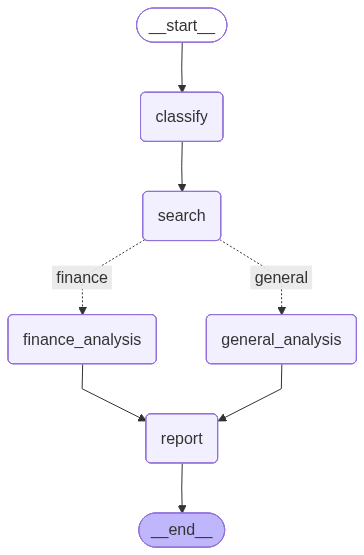

In [9]:
# Optional: visualize the graph structure (requires graphviz/mermaid extras;
# falls back to ASCII if unavailable).
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization unavailable:", e)
    print(app.get_graph().draw_ascii())


## 6. Run it — finance branch

In [10]:
result_finance = app.invoke({
    "question": "What is Apple's current stock price and how has it trended this year?",
    "topic": "",
    "facts": "",
    "analysis": "",
    "report": "",
})

print("\nTopic routed to:", result_finance["topic"])
print("\n=== FINAL REPORT ===")
print(result_finance["report"])


[classify_topic] topic = finance


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=

[search_node] facts gathered


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[finance_analysis_node] analysis complete
[report_node] report written

Topic routed to: finance

=== FINAL REPORT ===
Apple's current stock price is 298.01, and it has shown strong growth over the past year, with a 42.42% increase. In the past 4 weeks, the stock price has risen by an additional 14.23%. With a P/E ratio of 29.9x, Apple's stock is considered to be trading at a premium valuation. However, without clear information about the trend of Apple's stock price this year, it is difficult to make definitive statements about its growth or comparisons to other companies. The strong 1-year and 4-week price changes suggest that Apple's stock has been performing well recently. (Market capitalization: $89.1 billion)


## 7. Run it — general branch

In [11]:
result_general = app.invoke({
    "question": "What is the tallest mountain in the world and how tall is it in feet?",
    "topic": "",
    "facts": "",
    "analysis": "",
    "report": "",
})

print("\nTopic routed to:", result_general["topic"])
print("\n=== FINAL REPORT ===")
print(result_general["report"])


[classify_topic] topic = general


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[search_node] facts gathered


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[general_analysis_node] analysis complete
[report_node] report written

Topic routed to: general

=== FINAL REPORT ===
The tallest mountain in the world, when measured from the ocean floor to its peak, is Mauna Kea in Hawaii. It stands at an impressive height of approximately 33,481 feet.


## Notes / extensions

- `route_by_topic` here is a simple keyword classifier for speed and
  determinism; swap it for an LLM-based classifier (ask the model "finance
  or general?" and parse the answer) for better generalization on phrasing
  the keyword list doesn't catch.
- Because every node returns a partial-state dict, LangGraph automatically
  merges it into the running state - nodes don't need to know about fields
  they don't touch.
- To compare against a role-based framework instead of a graph-based one,
  the same five responsibilities (classify, search, finance-analyze,
  general-analyze, report) map directly onto CrewAI `Agent`/`Task`
  definitions with a `Crew` as the orchestrator - the main change needed is
  routing CrewAI's LLM calls through a local HF pipeline (e.g. via
  `langchain_community.llms.HuggingFacePipeline` + CrewAI's LiteLLM
  integration) instead of a hosted API key.
